# TP 2 : Cibler une campagne téléphonique bancaire

**Classification : niveau débutant : environ 2 h : corrigé**

## Mise en situation

Tu es data scientist dans une banque de détail. Le service marketing lance chaque trimestre
une campagne téléphonique pour vendre un **dépôt à terme** (un placement bloqué, rémunéré).
Le bilan de la dernière campagne est le suivant : 45 000 clients appelés, **un peu moins de
12 % ont souscrit**. Les 88 % restants ont coûté du temps de conseiller, et agacé des
clients.

Le directeur marketing te pose sa question :

> **À partir de ce que la banque sait déjà de ses clients (âge, métier, solde du compte,
> crédits en cours, historique des campagnes précédentes), peut-on prédire qui va souscrire,
> et donc n'appeler que les clients les plus prometteurs ?**



Les données sont publiques : ce sont celles d'une banque portugaise, mises à disposition par
l'UCI Machine Learning Repository et téléchargées ici depuis OpenML. Une ligne = un client
appelé lors de la campagne.

> Le chargement télécharge les données la première fois (connexion internet nécessaire),
> puis les met en cache sur ta machine.

## Ce que tu vas faire

| Étape | Ce que tu apprends |
|---|---|
| 1. Manipuler les données | charger, inspecter un jeu mêlant nombres et catégories |
| 2. Explorer les données | lire un taux de souscription, repérer les segments qui répondent |
| 3. Préparer les données | construire la cible binaire et éliminer une variable qui triche |
| 4. Nettoyer les données | les `unknown`, et les valeurs codées en douce comme `-1` |
| 5. Ton premier modèle | un `Pipeline` qui encode les catégories et entraîne une régression logistique |
| 6. Évaluer le modèle | pourquoi l'accuracy ment ici : matrice de confusion, precision, recall, AUC |
| 7. Comparer les modèles | régler un Random Forest par `GridSearchCV`, tester XGBoost, gérer le déséquilibre des classes, choisir le meilleur |
| 8. Verdict final | évaluer une fois sur le jeu de test et chiffrer le gain pour le marketing |

## Comment lire ce corrigé

- Chaque exercice garde sa consigne de l'énoncé, suivie directement du code attendu.
- Les sorties sont enregistrées : le corrigé se lit sans rien exécuter.
- Pour le rejouer entièrement : menu Run, puis Run All Cells.
- Les chiffres cités dans les encadrés **Ce que tu devrais observer** proviennent de cette
  exécution.

In [11]:
# Cellule a executer une fois, au debut du TP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Librairies chargées.")

Librairies chargées.


---
## Étape 1 : Manipuler les données

### Le dictionnaire des données

**Le client**

| Colonne | Signification |
|---|---|
| `age` | âge du client |
| `job` | catégorie professionnelle (12 modalités) |
| `marital` | situation familiale : `married`, `single`, `divorced` |
| `education` | niveau d'études : `primary`, `secondary`, `tertiary`, `unknown` |
| `default` | le client a-t-il un incident de paiement en cours ? |
| `balance` | solde annuel moyen du compte, en euros |
| `housing` | a-t-il un crédit immobilier en cours ? |
| `loan` | a-t-il un crédit à la consommation en cours ? |

**Le dernier appel de la campagne en cours**

| Colonne | Signification |
|---|---|
| `contact` | moyen de contact : `cellular`, `telephone`, `unknown` |
| `day` / `month` | jour et mois du dernier appel |
| `duration` | **durée du dernier appel, en secondes** |

**L'historique**

| Colonne | Signification |
|---|---|
| `campaign` | nombre d'appels passés à ce client pendant cette campagne |
| `pdays` | nombre de jours depuis le dernier contact d'une campagne précédente (**-1 = jamais contacté**) |
| `previous` | nombre de contacts avant cette campagne |
| `poutcome` | résultat de la campagne précédente : `success`, `failure`, `other`, `unknown` |
| `y` | **la cible** : le client a-t-il souscrit ? `yes` / `no` |

Garde un œil sur `duration` : cette colonne est un piège, et tu le découvriras à l'étape 2.

### Exercice 1.1 : Charger et regarder

Charge le jeu de données, puis affiche ses dimensions, ses trois premières lignes et le type
de chaque colonne.

Indice : `fetch_openml(data_id=44234, as_frame=True).frame` renvoie un DataFrame pandas
complet.

In [12]:
from sklearn.datasets import fetch_openml

clients = fetch_openml(data_id=44234, as_frame=True).frame

print("Dimensions (lignes, colonnes) :", clients.shape)
display(clients.head(3))
print(clients.dtypes)

Dimensions (lignes, colonnes) : (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


**Ce que tu devrais observer** : 45 211 clients et 17 colonnes. Contrairement au TP de
régression, **toutes les colonnes ne sont pas numériques** : `job`, `marital`, `month`,
`poutcome`... contiennent du texte. Ce sont des **variables catégorielles**, et un modèle
mathématique ne sait pas les additionner. Il faudra les transformer en nombres à l'étape 5.

### Exercice 1.2 : Interroger le tableau

1. Combien de clients ont souscrit, et quelle proportion cela représente-t-il ?
   (`clients["y"].value_counts()` puis `value_counts(normalize=True)`)
2. Quelles sont les statistiques des colonnes numériques ? (`.describe()`)
3. Quelles sont les 12 catégories professionnelles, et leurs effectifs ?

In [13]:
print("Repartition de la cible :")
print(clients["y"].value_counts())
print()
print((clients["y"].value_counts(normalize=True) * 100).round(1))

display(clients.describe().round(1))

print("Categories professionnelles :")
print(clients["job"].value_counts())

Repartition de la cible :
y
no     39922
yes     5289
Name: count, dtype: int64

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


,age,balance,day,duration,campaign,pdays,previous
count,45211.0,45211.0,45211.0,45211.0,45211.0,45211.0,45211.0
mean,40.9,1362.3,15.8,258.2,2.8,40.2,0.6
std,10.6,3044.8,8.3,257.5,3.1,100.1,2.3
min,18.0,-8019.0,1.0,0.0,1.0,-1.0,0.0
25%,33.0,72.0,8.0,103.0,1.0,-1.0,0.0
50%,39.0,448.0,16.0,180.0,2.0,-1.0,0.0
75%,48.0,1428.0,21.0,319.0,3.0,-1.0,0.0
max,95.0,102127.0,31.0,4918.0,63.0,871.0,275.0


Categories professionnelles :
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


**Ce que tu devrais observer** : 5 289 clients ont souscrit sur 45 211, soit **11,7 %**. Les
deux classes sont donc très **déséquilibrées** : pour un « oui », il y a presque huit
« non ». Retiens ce chiffre de 11,7 %, il sera la clé de l'étape 6.

Côté variables numériques, deux colonnes surprennent déjà : `balance` descend à -8 019 euros
(des comptes à découvert) et `pdays` vaut -1 au minimum, ce qui n'a aucun sens pour un
nombre de jours. On s'en occupera à l'étape 4.

---
## Étape 2 : Explorer les données

**Question de réflexion :** avec 11,7 % de souscriptions en moyenne, qu'est-ce qui serait
utile au marketing ? Connaître les segments dont le taux **s'écarte** franchement de cette
moyenne.

C'est la logique de l'exploration en classification : on compare toujours le taux d'un
groupe au **taux global**.

### Exercice 2.1 : Le taux de souscription, segment par segment

Pour `job`, `housing` et `poutcome`, calcule le pourcentage de clients qui ont souscrit dans
chaque modalité, trié par ordre décroissant.

Indice : `clients.groupby("job")["y"].apply(lambda s: (s == "yes").mean() * 100)`, puis
`.sort_values(ascending=False).round(1)`.

In [14]:
def taux_par_modalite(colonne):
    taux = clients.groupby(colonne)["y"].apply(lambda s: (s == "yes").mean() * 100)
    return taux.sort_values(ascending=False).round(1)

for colonne in ["job", "housing", "poutcome"]:
    print(f"--- Taux de souscription par {colonne} (moyenne generale : 11,7 %) ---")
    print(taux_par_modalite(colonne))
    print()

--- Taux de souscription par job (moyenne generale : 11,7 %) ---
job
student          28.7
retired          22.8
unemployed       15.5
management       13.8
admin.           12.2
self-employed    11.8
unknown          11.8
technician       11.1
services          8.9
housemaid         8.8
entrepreneur      8.3
blue-collar       7.3
Name: y, dtype: float64

--- Taux de souscription par housing (moyenne generale : 11,7 %) ---
housing
no     16.7
yes     7.7
Name: y, dtype: float64

--- Taux de souscription par poutcome (moyenne generale : 11,7 %) ---
poutcome
success    64.7
other      16.7
failure    12.6
unknown     9.2
Name: y, dtype: float64



**Ce que tu devrais observer**, et ce que ça raconte côté métier :

- **`job`** : les étudiants (28,7 %) et les retraités (22,8 %) souscrivent deux à trois fois
  plus que la moyenne, les ouvriers (`blue-collar`, 7,3 %) deux fois moins. Un produit
  d'épargne bloquée parle à ceux qui ont du temps devant eux ou un capital à placer.
- **`housing`** : 16,7 % sans crédit immobilier contre 7,7 % avec. Logique : quand on
  rembourse un prêt, on n'immobilise pas son épargne.
- **`poutcome`** : **64,7 %** des clients qui avaient déjà dit oui lors d'une campagne
  précédente disent oui à nouveau. C'est de très loin le signal le plus fort du jeu de
  données. En marketing, c'est une règle connue : le meilleur prospect est un client.

Prudence quand même : un taux calculé sur peu de clients est peu fiable. Regarde toujours
l'effectif du segment (`value_counts`) avant de tirer une conclusion.

### Exercice 2.2 : L'âge, et la forme des relations

Trace deux graphiques :

1. La distribution de l'âge des clients qui ont souscrit, superposée à celle des autres
   (`sns.histplot(data=clients, x="age", hue="y", ...)`).
2. Le taux de souscription par tranche d'âge. Crée d'abord la tranche avec
   `pd.cut(clients["age"], bins=[17, 30, 40, 50, 60, 100])`, puis applique le même
   `groupby` qu'à l'exercice précédent.

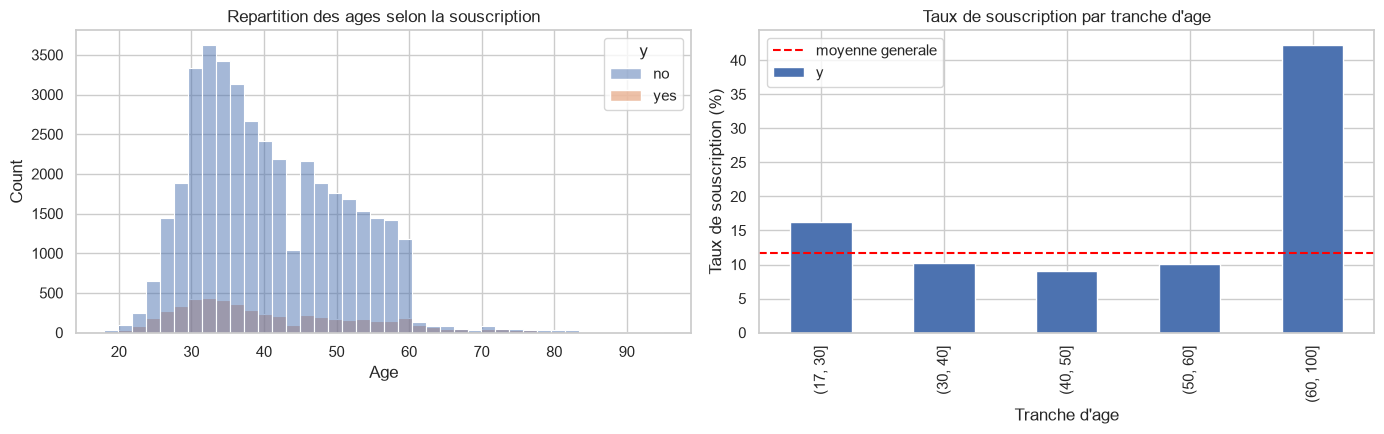

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(data=clients, x="age", hue="y", bins=40, ax=axes[0])
axes[0].set_title("Repartition des ages selon la souscription")
axes[0].set_xlabel("Age")

tranche = pd.cut(clients["age"], bins=[17, 30, 40, 50, 60, 100])
taux_age = clients.groupby(tranche, observed=True)["y"].apply(lambda s: (s == "yes").mean() * 100)
taux_age.plot(kind="bar", ax=axes[1], color="#4C72B0")
axes[1].axhline(11.7, color="red", linestyle="--", label="moyenne generale")
axes[1].set_ylabel("Taux de souscription (%)")
axes[1].set_xlabel("Tranche d'age")
axes[1].set_title("Taux de souscription par tranche d'age")
axes[1].legend()

plt.tight_layout()
plt.show()

**Ce que tu devrais observer** : le taux de souscription dessine un **U**, 16,3 % chez les
moins de 30 ans, puis un creux à 10,2 %, 9,1 % et 10,1 % entre 30 et 60 ans, et enfin
**42,3 % au-delà de 60 ans**. Les seniors sont de loin la cible la plus rentable de cette
campagne, ce qui rejoint les 22,8 % des retraités vus à l'exercice précédent.

Vérifie quand même l'effectif de cette dernière tranche : 1 188 clients seulement, contre
17 687 pour la tranche 30-40 ans. Le taux reste solide sur plus de mille personnes, mais le
réflexe doit être automatique, un taux spectaculaire sur trente clients ne vaut rien.

Retiens aussi la leçon de lecture : une relation en U **n'apparaît pas** dans un coefficient
de corrélation, qui ne mesure qu'une tendance « plus de ceci, plus de cela ». Un graphique
voit ce qu'un chiffre unique manque.

### Exercice 2.3 : Le piège : la colonne `duration`

Compare la durée moyenne des appels selon que le client a souscrit ou non, puis pose-toi la
question qui suit : elle compte plus que le code.

In [16]:
print(clients.groupby("y")["duration"].agg(["mean", "median", "count"]).round(1))

      mean  median  count
y                        
no   221.2   164.0  39922
yes  537.3   426.0   5289


**Ce que tu devrais observer** : un appel qui se conclut par une souscription dure en moyenne
**537 secondes** (9 minutes), contre **221 secondes** (moins de 4 minutes) sinon. Une
variable qui sépare aussi bien les deux classes ressemble à une aubaine.

**Question de réflexion, la plus importante du TP :** à quel moment connaît-on la valeur de
`duration` ?

Réponse : **après l'appel**. Or le modèle doit désigner qui appeler, donc **avant**. Une
variable qui n'existe pas au moment où l'on doit décider s'appelle une **fuite de données**
(*data leakage*). Elle donne des scores spectaculaires en TP et un modèle inutilisable en
production : c'est l'une des erreurs les plus fréquentes chez les débutants, et elle ne se
détecte pas dans les chiffres : elle se détecte en se demandant **quand** chaque information
devient disponible.

À l'étape 3, on jettera donc `duration`.

---
## Étape 3 : Préparer les données

Deux gestes ici :

1. **Construire la cible binaire.** Les modèles de scikit-learn attendent des nombres :
   `yes` devient 1, `no` devient 0. Par convention, **1 est la classe qui nous intéresse**
   (ici la souscription), celle dont on parlera comme la classe « positive ».
2. **Choisir les variables explicatives.** Tout ce qui sera connu avant l'appel : donc tout,
   sauf `y` et sauf `duration`.

### Exercice 3.1 : Cible binaire et variables explicatives

1. Crée une copie du DataFrame, nommée `donnees`, avec une colonne `souscrit` valant 1 ou 0.
2. Construis `y` (la colonne `souscrit`) et `X` (toutes les colonnes sauf `y`, `souscrit` et
   `duration`).
3. Vérifie les dimensions et le taux de 1 dans `y`.

Indice : `(donnees["y"] == "yes").astype(int)` transforme un booléen en 0/1.

In [17]:
donnees = clients.copy()
donnees["souscrit"] = (donnees["y"] == "yes").astype(int)

y = donnees["souscrit"]
X = donnees.drop(columns=["y", "souscrit", "duration"])

print("X :", X.shape, "| y :", y.shape)
print("Colonnes de X :", list(X.columns))
print(f"Proportion de souscriptions : {y.mean() * 100:.1f} %")

X : (45211, 15) | y : (45211,)
Colonnes de X : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']
Proportion de souscriptions : 11.7 %


**Ce que tu devrais observer** : `X` contient 45 211 lignes et **15 colonnes** (les 16
variables moins `duration`), et `y` vaut 1 pour 11,7 % des clients.

Tu viens de renoncer volontairement à la variable la plus prédictive du jeu de données. Ce
n'est pas un sacrifice, c'est la condition pour que le modèle serve à quelque chose.

---
## Étape 4 : Nettoyer les données

**Question de réflexion :** `clients.isna().sum()` ne renvoie que des zéros. Peut-on en
conclure qu'il n'y a pas de valeur manquante ?

Non. Une information absente peut être **déguisée** : un `"unknown"` dans une colonne texte,
un `-1` ou un `0` dans une colonne numérique. Pandas ne les voit pas, ton œil doit les voir.

### Exercice 4.1 : Traquer les manquants déguisés

1. Vérifie les valeurs manquantes déclarées (`.isna().sum().sum()`) et les doublons.
2. Pour chaque colonne de type texte, compte le nombre et le pourcentage de `"unknown"`.
3. Compte combien de clients ont `pdays == -1`.

Indice pour le point 2 : récupère d'abord les colonnes non numériques avec
`X.select_dtypes(include="number").columns`, puis prends celles qui n'y sont pas.

In [18]:
print("Valeurs manquantes declarees :", X.isna().sum().sum())
print("Lignes dupliquees :", donnees.duplicated().sum())

colonnes_numeriques = X.select_dtypes(include="number").columns.tolist()
colonnes_texte = [c for c in X.columns if c not in colonnes_numeriques]

print("\nValeurs 'unknown' par colonne :")
for colonne in colonnes_texte:
    nombre = (X[colonne] == "unknown").sum()
    if nombre > 0:
        print(f"  {colonne:12s} {nombre:6d}  ({nombre / len(X) * 100:4.1f} %)")

jamais_contacte = (X["pdays"] == -1)
print(f"\nClients avec pdays = -1 : {jamais_contacte.sum()} ({jamais_contacte.mean() * 100:.1f} %)")

Valeurs manquantes declarees : 0
Lignes dupliquees : 0

Valeurs 'unknown' par colonne :
  job             288  ( 0.6 %)
  education      1857  ( 4.1 %)
  contact       13020  (28.8 %)
  poutcome      36959  (81.7 %)

Clients avec pdays = -1 : 36954 (81.7 %)


**Ce que tu devrais observer** : aucune valeur manquante déclarée, aucun doublon... mais
quatre colonnes contiennent des `unknown` :

| Colonne | `unknown` | Que faire ? |
|---|---|---|
| `job` | 288 (0,6 %) | négligeable, on garde la modalité |
| `education` | 1 857 (4,1 %) | on garde : « niveau d'études non renseigné » est une information en soi |
| `contact` | 13 020 (28,8 %) | on garde : c'est un ancien mode de saisie, et il est peut-être lié au résultat |
| `poutcome` | 36 959 (81,7 %) | on garde : cela signifie « aucune campagne précédente » |

Le réflexe du débutant est de supprimer ces lignes : ici, cela reviendrait à jeter 82 % du
jeu de données. Le bon réflexe est de se demander **pourquoi** la valeur est absente. Pour
`poutcome`, l'absence n'est pas une erreur de saisie : c'est un fait (ce client est un
nouveau prospect). On la traite donc comme une catégorie à part entière.

Et 36 954 clients (81,7 %) ont `pdays = -1`, ce qui est cohérent : ce sont les mêmes clients,
ceux qui n'ont jamais été contactés auparavant.

### Exercice 4.2 : Traiter la valeur sentinelle `-1`

Le `-1` de `pdays` est dangereux : c'est un **code**, pas une durée. Un modèle linéaire, lui,
le lira comme « il y a -1 jour », c'est-à-dire une valeur toute proche de « contacté hier ».
Alors que ces clients sont à l'opposé : ils n'ont **jamais** été contactés.

La solution standard, en deux temps :

1. créer une colonne `deja_contacte` qui vaut 1 si `pdays != -1`, 0 sinon (on garde
   l'information) ;
2. remplacer le `-1` par 0 dans `pdays` (on neutralise le code).

Fais-le sur une copie nommée `X_propre`, puis construis les deux listes de colonnes,
`col_num` et `col_cat` : tu en auras besoin à l'étape 5.

In [19]:
X_propre = X.copy()
X_propre["deja_contacte"] = (X_propre["pdays"] != -1).astype(int)
X_propre["pdays"] = X_propre["pdays"].replace(-1, 0)

col_num = X_propre.select_dtypes(include="number").columns.tolist()
col_cat = [c for c in X_propre.columns if c not in col_num]

print("Colonnes numeriques  :", col_num)
print("Colonnes categorielles :", col_cat)
print("\npdays apres nettoyage : min =", X_propre["pdays"].min(), "| max =", X_propre["pdays"].max())

Colonnes numeriques  : ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'deja_contacte']
Colonnes categorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

pdays apres nettoyage : min = 0 | max = 871


**Ce que tu devrais observer** : 7 colonnes numériques (dont la nouvelle `deja_contacte`) et
8 colonnes catégorielles. `pdays` ne descend plus en dessous de 0.

Ce geste porte un nom : c'est du **feature engineering**. On n'a pas ajouté de données, on a
rendu lisible par le modèle une information qui était codée en douce.

---
## Étape 5 : Ton premier modèle

Comme dans le TP de régression, on découpe en trois : **entraînement** (64 %),
**validation** (16 %) et **test** (20 %), ce dernier mis au coffre jusqu'à l'étape 8.

Une précaution supplémentaire ici : avec seulement 11,7 % de « oui », un tirage malchanceux
pourrait déséquilibrer les jeux. On utilise donc `stratify=y`, qui garantit **la même
proportion de souscriptions dans chaque morceau**.

### Exercice 5.1 : Découper en préservant les proportions

Découpe `X_propre` / `y` en test (20 %), puis le reste en apprentissage / validation (20 %),
avec `random_state=42` et `stratify` à chaque fois. Vérifie ensuite le taux de souscription
dans chacun des trois jeux.

Attention : pour le second découpage, `stratify` doit porter sur `y_train`, pas sur `y`.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_propre, y, test_size=0.2, random_state=42, stratify=y
)
X_ap, X_val, y_ap, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

for nom, jeu in [("Entrainement", y_ap), ("Validation", y_val), ("Test (au coffre)", y_test)]:
    print(f"{nom:18s} {len(jeu):6d} clients | {jeu.mean() * 100:.1f} % de souscriptions")

Entrainement        28934 clients | 11.7 % de souscriptions
Validation           7234 clients | 11.7 % de souscriptions
Test (au coffre)     9043 clients | 11.7 % de souscriptions


**Ce que tu devrais observer** : 28 934 clients pour apprendre, 7 234 pour valider, 9 043 au
coffre : et **11,7 % de souscriptions dans chacun des trois**. C'est exactement ce que fait
`stratify` : sans lui, ces taux varieraient d'un jeu à l'autre, et les scores deviendraient
incomparables.

### Exercice 5.2 : Un `Pipeline` : préparer et entraîner en un seul objet

La régression logistique ne sait traiter que des nombres. Il faut donc, avant elle :

- **encoder les catégories** avec un `OneHotEncoder` : la colonne `marital` devient trois
  colonnes 0/1 (`marital_married`, `marital_single`, `marital_divorced`). On passe
  `handle_unknown="ignore"` pour qu'une modalité jamais vue à l'entraînement ne fasse pas
  planter la prédiction ;
- **standardiser les colonnes numériques** avec un `StandardScaler`, pour que `balance` (des
  milliers d'euros) ne domine pas `age` (des dizaines d'années).

Le `ColumnTransformer` applique chaque traitement aux bonnes colonnes, et le `Pipeline`
enchaîne préparation et modèle dans un seul objet.

**Pourquoi c'est important :** un `Pipeline` n'apprend ses transformations (les moyennes du
scaler, les modalités de l'encodeur) que sur les données d'entraînement, à chaque `fit`. En
cross-validation, cela évite qu'une information du pli d'évaluation ne se glisse dans la
préparation. C'est la protection anti-fuite la plus efficace du métier : et, accessoirement,
un seul objet à sauvegarder pour la mise en production.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preparation = ColumnTransformer([
    ("num", StandardScaler(), col_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), col_cat),
])

modele = Pipeline([
    ("preparation", preparation),
    ("modele", LogisticRegression(max_iter=1000)),
]).fit(X_ap, y_ap)

naif = DummyClassifier(strategy="most_frequent").fit(X_ap, y_ap)

print("Colonnes apres encodage :", modele.named_steps["preparation"].transform(X_ap).shape[1])

apercu = pd.DataFrame({
    "souscrit_reel": y_val.head(5).values,
    "probabilite_predite": modele.predict_proba(X_val.head(5))[:, 1].round(3),
    "prediction": modele.predict(X_val.head(5)),
})
display(apercu)

Colonnes apres encodage : 51


,souscrit_reel,probabilite_predite,prediction
0,1,0.165,0
1,0,0.156,0
2,1,0.663,1
3,0,0.014,0
4,0,0.025,0


**Ce que tu devrais observer** : les 15 colonnes de départ sont devenues **51 colonnes**
après encodage : c'est le `OneHotEncoder` qui a éclaté chaque catégorie.

Surtout, regarde les probabilités : le modèle ne répond pas « oui » ou « non », il donne une
**probabilité de souscription** pour chaque client (par exemple 0,03, 0,12, 0,41...). C'est
`predict` qui tranche ensuite, en appliquant le seuil par défaut de **0,5**. Ce seuil est un
choix, pas une vérité : on le remettra en cause à l'étape 6.

---
## Étape 6 : Évaluer le modèle

**Question de réflexion :** un modèle qui prédirait « personne ne souscrit » pour les
45 000 clients aurait 88,3 % de bonnes réponses. Est-ce un bon modèle ?

### Exercice 6.1 : L'accuracy, et pourquoi elle ment ici

Calcule l'accuracy (la proportion de prédictions correctes) du modèle naïf et de la
régression logistique sur le jeu de validation, puis compte combien de souscripteurs chacun
a identifiés.

Indice : `accuracy_score(y_val, modele.predict(X_val))`, et
`modele.predict(X_val).sum()` donne le nombre de clients que le modèle désigne comme
souscripteurs.

In [22]:
from sklearn.metrics import accuracy_score

for nom, un_modele in [("modele naif", naif), ("regression logistique", modele)]:
    predictions = un_modele.predict(X_val)
    print(f"{nom:24s} accuracy {accuracy_score(y_val, predictions):.3f} "
          f"| clients designes : {predictions.sum():4d}")

print("\nSouscripteurs reellement presents dans la validation :", y_val.sum())

modele naif              accuracy 0.883 | clients designes :    0
regression logistique    accuracy 0.894 | clients designes :  222

Souscripteurs reellement presents dans la validation : 846


**Ce que tu devrais observer** :

| Modèle | Accuracy | Clients désignés |
|---|---|---|
| modèle naïf | 0,883 | 0 |
| régression logistique | 0,894 | 222 |

Le modèle naïf obtient **88,3 % de bonnes réponses en ne désignant personne**. Il se contente
de répondre « non » 7 234 fois, et il a raison 88,3 % du temps, puisque 88,3 % des clients ne
souscrivent pas. Un score de 88 % qui ne sert strictement à rien.

Et notre modèle ? 89,4 %, à peine mieux. Pourtant il a identifié 222 clients. **L'accuracy
est incapable de faire la différence entre ces deux modèles** : c'est la métrique la plus
trompeuse dès que les classes sont déséquilibrées. Il faut regarder *quelles* erreurs sont
commises.

### Exercice 6.2 : La matrice de confusion, precision et recall

La matrice de confusion croise la réalité et la prédiction :

|  | prédit : non | prédit : oui |
|---|---|---|
| **réellement non** | vrais négatifs (VN) | **faux positifs (FP)** : on appelle pour rien |
| **réellement oui** | **faux négatifs (FN)** : on rate un client | vrais positifs (VP) |

Deux métriques en découlent, et elles répondent à deux questions métier différentes :

- **Precision** = VP / (VP + FP) : *quand le modèle dit « appelle-le », a-t-il raison ?*
  C'est le rendement des appels passés.
- **Recall** = VP / (VP + FN) : *quelle part des souscripteurs le modèle a-t-il retrouvés ?*
  C'est le chiffre d'affaires capté.
- **F1-score** : la moyenne harmonique des deux, pour résumer d'un chiffre.

Affiche la matrice de confusion de la régression logistique, puis ses precision, recall et
F1.

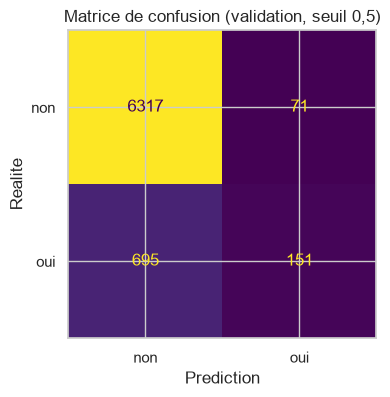

Precision : 0.680
Recall    : 0.178
F1-score  : 0.283


In [23]:
from sklearn.metrics import (ConfusionMatrixDisplay, f1_score, precision_score,
                             recall_score)

predictions_val = modele.predict(X_val)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, predictions_val, display_labels=["non", "oui"], colorbar=False, ax=ax
)
ax.set_title("Matrice de confusion (validation, seuil 0,5)")
ax.set_xlabel("Prediction")
ax.set_ylabel("Realite")
plt.show()

print(f"Precision : {precision_score(y_val, predictions_val):.3f}")
print(f"Recall    : {recall_score(y_val, predictions_val):.3f}")
print(f"F1-score  : {f1_score(y_val, predictions_val):.3f}")

**Ce que tu devrais observer** : la matrice donne 6 317 VN, 71 FP, 695 FN et 151 VP.
Traduction en français :

- **Precision 0,680** : sur les 222 clients que le modèle désigne, 151 souscrivent vraiment.
  Deux appels sur trois aboutissent, contre un sur huit en appelant au hasard. Excellent.
- **Recall 0,178** : mais sur les 846 souscripteurs présents, le modèle n'en retrouve que
  151. **Il en laisse passer 695.**

Le modèle est donc très prudent : il ne se mouille que lorsqu'il est certain. C'est le seuil
de 0,5 qui produit ce comportement, et pour une campagne marketing, c'est probablement trop
timide : un appel coûte quelques euros, une souscription en rapporte beaucoup plus. Il vaut
mieux accepter des appels inutiles que de rater des clients.

Retiens surtout : **precision et recall varient en sens inverse**, et choisir entre les deux
n'est pas une décision technique, c'est une décision métier.

### Exercice 6.3 : Le seuil de décision, l'AUC, et le vrai livrable

Le modèle produit une probabilité ; le seuil transforme cette probabilité en décision. Ici,
le service marketing ne veut pas vraiment une réponse oui/non : il veut une **liste de
clients à appeler, classée par ordre de priorité**. Notre probabilité fait exactement cela.

1. Construis un tableau donnant, pour les seuils 0,5 / 0,3 / 0,2 / 0,1 : le nombre de
   clients appelés, la precision et le recall.
2. Calcule l'AUC (`roc_auc_score`) et trace la courbe ROC.
3. Classe les clients de la validation par probabilité décroissante et regarde ce que donne
   le fait de n'appeler que les **20 % les mieux notés**.

Indices : `probas_val = modele.predict_proba(X_val)[:, 1]`, puis
`(probas_val >= seuil).astype(int)`. Pour le classement : `np.argsort(-probas_val)`.

,seuil,clients appeles,precision,recall
0,0.5,222,0.680,0.178
1,0.3,509,0.552,0.332
2,0.2,819,0.453,0.439
3,0.1,2782,0.218,0.717


AUC : 0.767


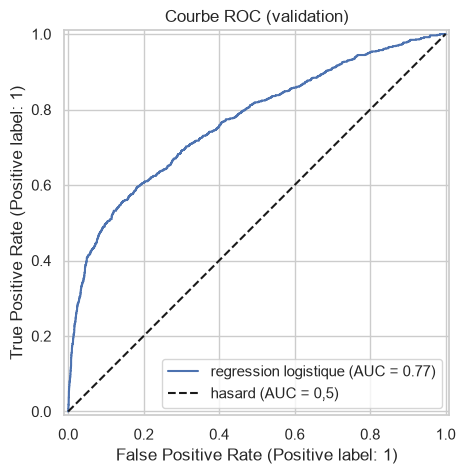

En appelant les 1446 clients les mieux notes (20 %) :
  souscripteurs captes : 474 sur 846 (56 %)
  taux de reussite des appels : 32.8 % (contre 11.7 % au hasard)


In [24]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

probas_val = modele.predict_proba(X_val)[:, 1]

lignes = []
for seuil in [0.5, 0.3, 0.2, 0.1]:
    predictions_seuil = (probas_val >= seuil).astype(int)
    lignes.append({
        "seuil": seuil,
        "clients appeles": int(predictions_seuil.sum()),
        "precision": precision_score(y_val, predictions_seuil, zero_division=0),
        "recall": recall_score(y_val, predictions_seuil, zero_division=0),
    })
display(pd.DataFrame(lignes).round(3))

print(f"AUC : {roc_auc_score(y_val, probas_val):.3f}")
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_val, probas_val, name="regression logistique", ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="hasard (AUC = 0,5)")
ax.set_title("Courbe ROC (validation)")
ax.legend()
plt.show()

classement = np.argsort(-probas_val)
nombre_appels = int(0.20 * len(probas_val))
cibles = y_val.to_numpy()[classement][:nombre_appels]
print(f"En appelant les {nombre_appels} clients les mieux notes (20 %) :")
print(f"  souscripteurs captes : {cibles.sum()} sur {y_val.sum()} ({cibles.sum() / y_val.sum() * 100:.0f} %)")
print(f"  taux de reussite des appels : {cibles.mean() * 100:.1f} % (contre {y_val.mean() * 100:.1f} % au hasard)")

**Ce que tu devrais observer** :

| Seuil | Clients appelés | Precision | Recall |
|---|---|---|---|
| 0,5 | 222 | 0,680 | 0,178 |
| 0,3 | 509 | 0,552 | 0,332 |
| 0,2 | 819 | 0,453 | 0,439 |
| 0,1 | 2 782 | 0,218 | 0,717 |

Le seuil est **le levier de pilotage de la campagne**. À 0,5, on passe 222 appels très
rentables mais on capte 18 % du potentiel. À 0,1, on passe douze fois plus d'appels et on
capte 72 % des souscripteurs, avec un rendement divisé par trois. Le bon seuil dépend du coût
d'un appel et de la marge d'une souscription : c'est au marketing de trancher, pas au modèle.

L'**AUC vaut 0,767**. Elle se lit ainsi : si on tire au hasard un souscripteur et un
non-souscripteur, le modèle donne une probabilité plus élevée au bon dans 76,7 % des cas.
Elle a un gros avantage : elle mesure la **qualité du classement**, indépendamment du seuil.
0,5 = hasard, 1 = parfait.

Et la conclusion qui intéresse vraiment le directeur marketing : **en n'appelant que les 20 %
de clients les mieux notés (1 446 appels), on capte 474 souscripteurs sur 846, soit 56 % du
potentiel, avec un appel sur trois qui aboutit** (32,8 %, contre 11,7 % aujourd'hui).

---
## Étape 7 : Comparer plusieurs modèles en cross-validation

**Question de réflexion :** tous ces chiffres viennent d'un seul jeu de validation, tiré au
hasard. Combien vaudraient-ils avec un autre tirage ? Et la régression logistique est-elle
le meilleur modèle possible pour ce problème ?

La cross-validation répond à la première question : on découpe le jeu d'entraînement en 5
plis, on entraîne 5 fois en laissant chaque fois un pli de côté pour l'évaluation, et on
obtient 5 scores : donc une moyenne **et** un écart-type.

En classification déséquilibrée, on utilise `StratifiedKFold` plutôt que `KFold` : il
garantit les mêmes 11,7 % de souscriptions dans chaque pli, pour la même raison que
`stratify` à l'étape 5.

On va s'en servir pour comparer trois modèles sur un pied d'égalité : même découpage, mêmes
métriques : explorer une deuxième façon de traiter le déséquilibre des classes (en plus du
seuil vu à l'étape 6), puis choisir le modèle qu'on emmène à l'étape 8.

### Exercice 7.1 : La régression logistique, comme référence

Lance une cross-validation du `Pipeline` sur `X_train` / `y_train`, avec
`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` et les métriques
`["accuracy", "precision", "recall", "f1", "roc_auc"]`. Affiche la moyenne et l'écart-type de
chacune.

Attention : passe un `Pipeline` **non entraîné** à `cross_validate`, qui se charge de le
ré-entraîner sur chaque pli. C'est précisément ce qui garantit l'absence de fuite.

On garde ces scores de côté : ils serviront de référence pour juger les deux modèles
suivants.

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate

pipeline_cv = Pipeline([
    ("preparation", preparation),
    ("modele", LogisticRegression(max_iter=1000)),
])

decoupage = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metriques = ["accuracy", "precision", "recall", "f1", "roc_auc"]

resultats_cv = cross_validate(pipeline_cv, X_train, y_train, cv=decoupage, scoring=metriques)

for nom in metriques:
    scores = resultats_cv["test_" + nom]
    print(f"{nom:10s} moyenne {scores.mean():.3f}   ecart-type {scores.std():.3f}")

accuracy   moyenne 0.892   ecart-type 0.001
precision  moyenne 0.643   ecart-type 0.014
recall     moyenne 0.175   ecart-type 0.011
f1         moyenne 0.275   ecart-type 0.013
roc_auc    moyenne 0.763   ecart-type 0.003


**Ce que tu devrais observer** :

| Métrique | Moyenne | Écart-type |
|---|---|---|
| accuracy | 0,892 | 0,001 |
| precision | 0,643 | 0,014 |
| recall | 0,175 | 0,011 |
| f1 | 0,275 | 0,013 |
| roc_auc | 0,763 | 0,003 |

Deux lectures :

1. **Les estimations sont stables.** L'AUC bouge de ±0,003 d'un pli à l'autre : on peut
   annoncer 0,76 sans trembler. La precision, elle, varie de ±0,014, car elle se calcule sur
   les quelques centaines de clients désignés : moins on mesure sur de monde, plus le chiffre
   danse.
2. **L'accuracy est d'un ennui total** : 0,892 ± 0,001, toujours collée aux 88,3 % du modèle
   naïf. Elle ne distinguerait pas un bon modèle d'un mauvais. Sur ce projet, la métrique à
   suivre est l'**AUC** (qualité du classement), puis la precision et le recall une fois le
   seuil choisi.

On retient l'AUC de référence, **0,763 ± 0,003**, pour juger les deux modèles suivants.

### Exercice 7.2 : Random Forest, réglé par `GridSearchCV`

Le Random Forest ne linéarise rien : chaque arbre découpe l'espace des variables selon des
seuils, et la forêt moyenne les votes de plusieurs centaines d'arbres. Il capture donc des
interactions et des effets non linéaires (comme le **U** de l'âge vu à l'étape 2) que la
régression logistique ne voit pas nativement.

Mais un Random Forest a plusieurs hyperparamètres qui pèsent sur la performance :
`n_estimators` (le nombre d'arbres), `max_depth` (la profondeur maximale) et
`min_samples_leaf` (la taille minimale d'une feuille, qui limite le sur-apprentissage). On en
profite pour tester aussi `class_weight` : `"balanced"` pénalise davantage les erreurs sur la
classe minoritaire (les 11,7 % de souscripteurs) pendant l'entraînement : une deuxième façon
d'agir sur le déséquilibre des classes, en plus du seuil de décision vu à l'exercice 6.3.
Plutôt que de régler tout ça à la main, `GridSearchCV` teste toutes les combinaisons d'une
grille et retient celle qui maximise un score de cross-validation.

1. Construis un `Pipeline` identique au précédent, mais avec un
   `RandomForestClassifier(random_state=42)`.
2. Définis une grille couvrant `n_estimators` (200 et 400 arbres), `max_depth` (8, 12 et
   sans limite), `min_samples_leaf` (1 et 5) et `class_weight` (`None` et `"balanced"`). Les
   paramètres du modèle se préfixent par `modele__` puisqu'il est dans un `Pipeline`.
3. Passe cette grille à `GridSearchCV`, avec le même découpage `StratifiedKFold` que
   l'exercice 7.1 et `scoring="roc_auc"` (c'est la métrique qu'on a retenue à l'étape 6).
4. Affiche les meilleurs paramètres (`grid_rf.best_params_`) puis relance une cross-validation
   complète (les 5 métriques) sur `grid_rf.best_estimator_`, pour comparer à l'exercice 7.1.

Attention : `GridSearchCV` prend une petite minute ici (24 combinaisons × 5 plis) : c'est
normal, il ré-entraîne un Random Forest à chaque fois.

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

pipeline_rf = Pipeline([
    ("preparation", preparation),
    ("modele", RandomForestClassifier(random_state=42)),
])

grille_rf = {
    "modele__n_estimators": [200, 400],
    "modele__max_depth": [8, 12, None],
    "modele__min_samples_leaf": [1, 5],
    "modele__class_weight": [None, "balanced"],
}

grid_rf = GridSearchCV(pipeline_rf, grille_rf, cv=decoupage, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Meilleurs parametres :", grid_rf.best_params_)
print("Meilleur AUC (grille) :", round(grid_rf.best_score_, 3))

pipeline_rf_best = grid_rf.best_estimator_
resultats_rf = cross_validate(pipeline_rf_best, X_train, y_train, cv=decoupage, scoring=metriques)

for nom in metriques:
    scores = resultats_rf["test_" + nom]
    print(f"{nom:10s} moyenne {scores.mean():.3f}   ecart-type {scores.std():.3f}")

/Users/mouaad/Formation/plb/formation-ds/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleurs parametres : {'modele__class_weight': None, 'modele__max_depth': 12, 'modele__min_samples_leaf': 1, 'modele__n_estimators': 400}
Meilleur AUC (grille) : 0.794
accuracy   moyenne 0.894   ecart-type 0.001
precision  moyenne 0.679   ecart-type 0.011
recall     moyenne 0.178   ecart-type 0.009
f1         moyenne 0.282   ecart-type 0.011
roc_auc    moyenne 0.794   ecart-type 0.005


**Ce que tu devrais observer** :

Meilleurs paramètres : `n_estimators=400`, `max_depth=12`, `min_samples_leaf=1`,
`class_weight=None`.

| Métrique | Moyenne | Écart-type |
|---|---|---|
| accuracy | 0,894 | 0,001 |
| precision | 0,679 | 0,011 |
| recall | 0,178 | 0,009 |
| f1 | 0,282 | 0,011 |
| roc_auc | 0,794 | 0,005 |

L'AUC passe de **0,763** (régression logistique) à **0,794** : un gain de 0,031, largement
supérieur à l'écart-type des deux modèles (0,003 et 0,005). Ce n'est pas du bruit : le
Random Forest capture réellement des effets que la régression logistique manque, comme les
interactions entre l'âge, le solde et le fait d'avoir déjà été contacté.

La precision progresse aussi (0,643 → 0,679) : à nombre d'appels comparable, la liste
priorisée par le Random Forest est plus fiable.

Et `class_weight="balanced"` ? La grille ne le retient **pas** : l'AUC mesure la qualité du
**classement** des clients par probabilité, et pénaliser la classe minoritaire à
l'entraînement ne change quasiment pas ce classement. Ça ne veut pas dire que
`class_weight` ne sert à rien : seulement qu'il n'agit pas là où `GridSearchCV` a cherché.
L'exercice 7.5 montre où il agit vraiment.

### Exercice 7.3 : Le gradient boosting avec XGBoost

Le Random Forest fait voter des arbres indépendants (**bagging**). Le gradient boosting
fonctionne différemment : il enchaîne les arbres, chaque nouvel arbre corrigeant les
erreurs du modèle formé par les précédents. XGBoost est l'implémentation la plus utilisée
de ce principe.

1. Construis un `Pipeline` avec un `XGBClassifier(n_estimators=300, max_depth=3,
   learning_rate=0.05, random_state=42, eval_metric="logloss")`. `max_depth=3` volontairement
   petit et `learning_rate=0.05` volontairement bas : le boosting préfère beaucoup d'arbres
   faibles à quelques arbres profonds, pour ne pas sur-apprendre.
2. Lance la même cross-validation à 5 métriques que pour les deux modèles précédents.

Pas de `GridSearchCV` ici : la grille d'XGBoost est plus large (profondeur, taux
d'apprentissage, nombre d'arbres, régularisation...) et sortirait du cadre de ce TP : retiens
simplement que la même logique de `GridSearchCV` vue à l'exercice 7.2 s'appliquerait.

In [27]:
from xgboost import XGBClassifier

pipeline_xgb = Pipeline([
    ("preparation", preparation),
    ("modele", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                              random_state=42, eval_metric="logloss")),
])

resultats_xgb = cross_validate(pipeline_xgb, X_train, y_train, cv=decoupage, scoring=metriques)

for nom in metriques:
    scores = resultats_xgb["test_" + nom]
    print(f"{nom:10s} moyenne {scores.mean():.3f}   ecart-type {scores.std():.3f}")

accuracy   moyenne 0.894   ecart-type 0.002
precision  moyenne 0.649   ecart-type 0.027
recall     moyenne 0.210   ecart-type 0.013
f1         moyenne 0.317   ecart-type 0.016
roc_auc    moyenne 0.796   ecart-type 0.003


**Ce que tu devrais observer** :

| Métrique | Moyenne | Écart-type |
|---|---|---|
| accuracy | 0,894 | 0,002 |
| precision | 0,649 | 0,027 |
| recall | 0,210 | 0,013 |
| f1 | 0,317 | 0,016 |
| roc_auc | 0,796 | 0,003 |

XGBoost obtient l'AUC la plus élevée des trois modèles (**0,796**), et surtout le meilleur
recall (0,210 contre 0,178 pour le Random Forest et 0,175 pour la régression logistique) :
il retrouve davantage de souscripteurs pour un seuil donné. Sa precision, en revanche, varie
plus d'un pli à l'autre (écart-type 0,027) : un signal à garder en tête plutôt qu'un défaut
rédhibitoire.

### Exercice 7.4 : Comparer et choisir

1. Rassemble les AUC moyennes (et les autres métriques) des trois modèles : régression
   logistique, Random Forest, XGBoost : dans un tableau.
2. Désigne le nom du modèle qui obtient la meilleure AUC moyenne (`meilleur_nom`).
3. Stocke le `Pipeline` correspondant dans `modele_choisi` : c'est lui qu'on emmène à
   l'étape 8.

Indice : `comparaison["roc_auc"].idxmax()` donne le nom du modèle gagnant.

In [28]:
comparaison = pd.DataFrame({
    "regression logistique": {nom: resultats_cv["test_" + nom].mean() for nom in metriques},
    "random forest": {nom: resultats_rf["test_" + nom].mean() for nom in metriques},
    "xgboost": {nom: resultats_xgb["test_" + nom].mean() for nom in metriques},
}).T

display(comparaison.round(3))

meilleur_nom = comparaison["roc_auc"].idxmax()
print("Modele retenu :", meilleur_nom)

pipelines_candidats = {
    "regression logistique": pipeline_cv,
    "random forest": pipeline_rf_best,
    "xgboost": pipeline_xgb,
}
modele_choisi = pipelines_candidats[meilleur_nom]

,accuracy,precision,recall,f1,roc_auc
regression logistique,0.892,0.643,0.175,0.275,0.763
random forest,0.894,0.679,0.178,0.282,0.794
xgboost,0.894,0.649,0.210,0.317,0.796


Modele retenu : xgboost


**Ce que tu devrais observer** :

| Modèle | AUC (moyenne) | Écart-type |
|---|---|---|
| régression logistique | 0,763 | 0,003 |
| random forest | 0,794 | 0,005 |
| xgboost | **0,796** | 0,003 |

XGBoost l'emporte de justesse (0,796 contre 0,794) : un écart de 0,002, plus petit que
l'écart-type des deux modèles : **statistiquement, Random Forest et XGBoost sont à
égalité.** Les deux, en revanche, dominent nettement la régression logistique (+0,03 d'AUC,
soit dix fois leur propre écart-type) : le problème contient des interactions non linéaires
qu'un modèle linéaire ne peut pas capturer, quel que soit son réglage.

`modele_choisi` retient XGBoost, à la faveur de ce dixième de point : mais dans un contexte
réel, l'égalité statistique avec le Random Forest inviterait à trancher sur d'autres
critères : temps d'entraînement, facilité d'interprétation, stabilité en production.

### Exercice 7.5 : Gérer le déséquilibre des classes : `class_weight` et `scale_pos_weight`

Rappel : seulement 11,7 % des clients souscrivent. `class_weight="balanced"` (Random Forest)
et `scale_pos_weight` (XGBoost) pénalisent davantage les erreurs sur la classe minoritaire
**pendant l'entraînement** : une autre façon d'agir sur le déséquilibre que le seuil de
décision vu à l'exercice 6.3, qui agit lui **après** l'entraînement, au moment de décider.

1. Reprends le Random Forest de l'exercice 7.2 (mêmes `n_estimators`, `max_depth`,
   `min_samples_leaf`), mais avec `class_weight="balanced"`. Lance la cross-validation à
   5 métriques.
2. Calcule le ratio négatifs / positifs dans `y_train`
   (`(y_train == 0).sum() / (y_train == 1).sum()`), et reprends le XGBoost de l'exercice 7.3
   avec ce ratio passé en `scale_pos_weight`. Même cross-validation.
3. Rassemble les quatre lignes (Random Forest et XGBoost, avec et sans pondération) dans un
   tableau, sur l'AUC, la precision et le recall.

In [29]:
# Random Forest, en penalisant la classe minoritaire
pipeline_rf_pondere = Pipeline([
    ("preparation", preparation),
    ("modele", RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=1,
        class_weight="balanced", random_state=42,
    )),
])
resultats_rf_pondere = cross_validate(pipeline_rf_pondere, X_train, y_train, cv=decoupage, scoring=metriques)

# XGBoost, en penalisant la classe minoritaire
ratio_classes = (y_train == 0).sum() / (y_train == 1).sum()
print("Ratio negatifs / positifs dans y_train :", round(ratio_classes, 2))

pipeline_xgb_pondere = Pipeline([
    ("preparation", preparation),
    ("modele", XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42,
        eval_metric="logloss", scale_pos_weight=ratio_classes,
    )),
])
resultats_xgb_pondere = cross_validate(pipeline_xgb_pondere, X_train, y_train, cv=decoupage, scoring=metriques)

comparaison_ponderation = pd.DataFrame({
    "random forest": {nom: resultats_rf["test_" + nom].mean() for nom in metriques},
    "random forest pondere": {nom: resultats_rf_pondere["test_" + nom].mean() for nom in metriques},
    "xgboost": {nom: resultats_xgb["test_" + nom].mean() for nom in metriques},
    "xgboost pondere": {nom: resultats_xgb_pondere["test_" + nom].mean() for nom in metriques},
}).T

display(comparaison_ponderation.round(3))

Ratio negatifs / positifs dans y_train : 7.55


,accuracy,precision,recall,f1,roc_auc
random forest,0.894,0.679,0.178,0.282,0.794
random forest pondere,0.827,0.355,0.582,0.441,0.792
xgboost,0.894,0.649,0.210,0.317,0.796
xgboost pondere,0.814,0.340,0.629,0.441,0.795


**Ce que tu devrais observer** :

| Modèle | AUC | Precision | Recall | F1 |
|---|---|---|---|---|
| random forest | 0,794 | 0,679 | 0,178 | 0,282 |
| random forest pondéré | 0,792 | 0,355 | **0,582** | 0,441 |
| xgboost | 0,796 | 0,649 | 0,210 | 0,317 |
| xgboost pondéré | 0,795 | 0,340 | **0,629** | 0,441 |

L'AUC ne bouge presque pas (±0,002, dans le bruit) : pondérer les classes ne change
quasiment pas le **classement** des clients par probabilité. Mais au seuil par défaut de
0,5, l'effet est spectaculaire : le recall triple (0,178 → 0,582 pour le Random Forest,
0,210 → 0,629 pour XGBoost), et la precision s'effondre en retour (0,679 → 0,355,
0,649 → 0,340). Le F1 progresse nettement, parce que le seuil de 0,5 était très conservateur
pour les modèles non pondérés.

C'est **le même compromis** que celui du seuil de décision à l'exercice 6.3 : `class_weight`
et `scale_pos_weight` le règlent au moment d'entraîner plutôt qu'au moment de décider. Pour
ce projet, où le livrable est une liste de clients classée (exercice 8.1), le seuil suffit :
on choisit directement le nombre d'appels souhaité sans réentraîner. La pondération devient
utile quand le modèle doit rendre une **décision unique et automatique** (accepter / refuser
un client en temps réel, par exemple) sans qu'un humain ne pilote de seuil derrière.

---

### Exercice 8.1 : L'épreuve de vérité, et le chiffrage métier

1. Réentraîne `modele_choisi` (déterminé à l'exercice 7.4) sur `X_train` / `y_train` en
   entier : c'est le modèle qui a gagné la comparaison, pas nécessairement la régression
   logistique.
2. Sur le jeu de test : accuracy, precision, recall, F1, AUC, et matrice de confusion.
3. Compare l'AUC obtenue à celle annoncée par la cross-validation (exercice 7.4).
4. Chiffre le gain : si le marketing n'appelle que les 20 % de clients les mieux notés du
   jeu de test, combien d'appels, combien de souscripteurs, et quel taux de réussite ?

In [30]:
from sklearn.metrics import confusion_matrix

modele_final = modele_choisi
modele_final.fit(X_train, y_train)

predictions_test = modele_final.predict(X_test)
probas_test = modele_final.predict_proba(X_test)[:, 1]

print("Modele evalue :", meilleur_nom)
print("Resultats sur le jeu de test :")
print(f"  accuracy  : {accuracy_score(y_test, predictions_test):.3f}")
print(f"  precision : {precision_score(y_test, predictions_test):.3f}")
print(f"  recall    : {recall_score(y_test, predictions_test):.3f}")
print(f"  f1        : {f1_score(y_test, predictions_test):.3f}")
print(f"  AUC       : {roc_auc_score(y_test, probas_test):.3f}")
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, predictions_test))

print(f"\nAUC annoncee par la cross-validation : {comparaison.loc[meilleur_nom, 'roc_auc']:.3f}")
print(f"AUC realisee sur le jeu de test      : {roc_auc_score(y_test, probas_test):.3f}")

classement_test = np.argsort(-probas_test)
nombre_appels = int(0.20 * len(probas_test))
cibles_test = y_test.to_numpy()[classement_test][:nombre_appels]

print(f"\n--- Scenario pour le service marketing ---")
print(f"Campagne actuelle : {len(y_test)} appels -> {y_test.sum()} souscriptions "
      f"({y_test.mean() * 100:.1f} % de reussite)")
print(f"Campagne ciblee   : {nombre_appels} appels -> {cibles_test.sum()} souscriptions "
      f"({cibles_test.mean() * 100:.1f} % de reussite)")
print(f"Soit {cibles_test.sum() / y_test.sum() * 100:.0f} % des souscripteurs captes "
      f"avec {100 - nombre_appels / len(y_test) * 100:.0f} % d'appels en moins.")

Modele evalue : xgboost
Resultats sur le jeu de test :
  accuracy  : 0.896
  precision : 0.675
  recall    : 0.218
  f1        : 0.330
  AUC       : 0.804

Matrice de confusion :
[[7874  111]
 [ 827  231]]

AUC annoncee par la cross-validation : 0.796
AUC realisee sur le jeu de test      : 0.804

--- Scenario pour le service marketing ---
Campagne actuelle : 9043 appels -> 1058 souscriptions (11.7 % de reussite)
Campagne ciblee   : 1808 appels -> 661 souscriptions (36.6 % de reussite)
Soit 62 % des souscripteurs captes avec 80 % d'appels en moins.


**Ce que tu devrais observer** :

| Métrique | Cross-validation (XGBoost) | Jeu de test |
|---|---|---|
| AUC | 0,796 | **0,804** |
| precision | 0,649 | 0,675 |
| recall | 0,210 | 0,218 |

La cross-validation annonçait 0,796 d'AUC pour XGBoost, le test donne 0,804 : la promesse est
tenue, et même légèrement dépassée : un jeu de test unique reste soumis au hasard du tirage,
comme le rappelle l'écart-type vu à l'exercice 7.1.

La matrice de confusion (7 874 VN, 111 FP, 827 FN, 231 VP) montre un modèle plus agressif que
la régression logistique de l'exercice 6.2 : il désigne moins prudemment, au prix de
quelques faux positifs de plus, mais il retrouve davantage de souscripteurs.

Et le chiffrage, qui est le vrai livrable :

> Campagne actuelle : **9 043 appels** pour **1 058 souscriptions** (11,7 % de réussite).
> Campagne ciblée sur les 20 % les mieux notés : **1 808 appels** pour **661 souscriptions**
> (36,6 % de réussite).
>
> **62 % des souscripteurs captés avec 80 % d'appels en moins** : contre 56 % avec la seule
> régression logistique (exercice 6.3) : le choix du modèle, pas seulement le seuil, pèse
> directement sur le résultat métier.

---
## La réponse au directeur marketing

> **Oui, on peut cibler.** Après avoir comparé trois modèles en cross-validation
> (régression logistique, Random Forest réglé par `GridSearchCV`, et XGBoost), le modèle
> retenu classe les clients par probabilité de souscription et atteint une AUC de 0,80 sur
> le jeu de test. En concentrant la campagne sur les 20 % de clients les mieux notés, on
> conserve **62 % des souscriptions** en passant **cinq fois moins d'appels** : un appel sur
> trois aboutit, contre un sur huit aujourd'hui.
>
> Le curseur reste entre vos mains : appeler plus de clients augmente le nombre de
> souscriptions et fait baisser le rendement de chaque appel. Donnez-nous le coût d'un appel
> et la marge d'une souscription, et on calcule le point d'équilibre.
>
> **Ce que le modèle a appris**, et qui recoupe votre intuition terrain : les meilleurs
> prospects sont les clients ayant déjà souscrit lors d'une campagne précédente (65 % de
> réussite), les plus de 60 ans, les étudiants, et les clients sans crédit immobilier en
> cours.

## À retenir

1. **L'accuracy ment sur des classes déséquilibrées.** Un modèle qui ne désigne personne
   obtient 88,3 %. Toujours comparer à un `DummyClassifier`, et regarder la matrice de
   confusion.
2. **Chaque métrique répond à une question métier.** Precision = rendement des appels,
   recall = chiffre d'affaires capté, AUC = qualité du classement. On choisit la métrique
   avant de modéliser, en fonction du coût des erreurs.
3. **Le seuil est un curseur métier**, pas une constante. 0,5 n'a rien de sacré.
4. **Le déséquilibre des classes se gère à deux niveaux.** Le seuil de décision (exercice
   6.3) agit après l'entraînement ; `class_weight` / `scale_pos_weight` (exercice 7.5) agit
   pendant l'entraînement, en pénalisant plus les erreurs sur la classe minoritaire. Les
   deux produisent le même type de compromis precision/recall, et ni l'un ni l'autre
   n'améliore l'AUC : ils déplacent la frontière de décision, pas la qualité du classement.
5. **Le choix du modèle se fait sur une cross-validation, pas sur un seul essai.**
   `GridSearchCV` explore les hyperparamètres d'un même modèle ; comparer plusieurs
   modèles (régression logistique, Random Forest, XGBoost) sur le même découpage montre
   lequel capture le mieux les interactions entre variables. Ici, Random Forest et XGBoost
   font jeu presque égal, et tous deux dominent nettement la régression logistique.
6. **Méfie-toi des variables trop belles.** `duration` aurait fait monter l'AUC à 0,91 et
   donné un modèle inutilisable : elle n'existe qu'après l'appel.
7. **Les manquants ne sont pas toujours déclarés.** `unknown`, `-1`, `0` : il faut les
   traquer à la main, et comprendre *pourquoi* la valeur est absente avant de décider.
8. **Le `Pipeline` n'est pas une coquetterie** : il garantit que l'encodage et la
   standardisation sont appris sur le seul jeu d'entraînement, à chaque pli : vrai pour un
   modèle linéaire comme pour un Random Forest ou un XGBoost.

## Pour aller plus loin

Ces pistes n'ont pas de corrigé : c'est à toi de jouer.

1. **Vérifie le piège** : refais tourner la cross-validation en gardant `duration` dans `X`.
   L'AUC monte à environ 0,91. Explique en trois phrases pourquoi ce modèle est pourtant
   inutilisable.
2. **Chiffre le point d'équilibre** : en supposant 5 € par appel et 150 € de marge par
   souscription, trace le profit en fonction du seuil et trouve le seuil optimal.